# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [19]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from Multifidelity_support import custom_activation, FourierLayer, getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity, Neural_network
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
from keras.models import load_model

from keras.utils import custom_object_scope
from keras.initializers import glorot_uniform

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az

from cuqi.distribution import Uniform, Gaussian,JointDistribution
from cuqi.sampler import MH
from cuqi.model import Model
from cuqi.geometry import Continuous1D, Discrete

In [20]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [21]:
custom_objects = {'custom_activation': custom_activation, 'glorot_uniform': glorot_uniform(), 'FourierLayer': FourierLayer}

with custom_object_scope(custom_objects):
    keras_model1 = load_model("LF_model.h5")
    keras_model2= load_model("2step_model.h5")

def NN_MF(q,K1,K2):
    out1=K1.predict(q)
 #   print(q.shape)
    #in2 = np.hstack((q, out1))
    in2=np.concatenate((q,out1),axis=1)

    approx_model_output=K2.predict(in2)
    return approx_model_output[:,0]

def MF_wrapper(q):
    q=np.c_[q, np.abs(np.sin(5*np.pi*q-5*np.pi/6))]
    return NN_MF(q,keras_model1,keras_model2)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


## Data Preparation

In [22]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_LF = "../DATA/reaction_diffusion_LF_46_d75.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)


In [23]:
dim=5
real_x = np.random.rand(dim)+0.5
closest_indices = np.argmin(np.abs(reaction_HF_test[:, np.newaxis] - real_x), axis=0)
nearest_x=reaction_HF_test[closest_indices]


In [24]:
reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = U_HF_test[:, -1, 44,44]
U_HF_test=normalization(U_HF_test)
nearest_U=U_HF_test[closest_indices]

reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
# U_HF_test_original=U_HF_test



# reaction_LF_test = normalization(reaction_LF_test)
# U_LF_test=U_LF_test[
#     :,
#      - 1,
#     12,12
# ]
# U_LF_test=normalization(U_LF_test)
# reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
# U_LF_test_original=U_LF_test


In [25]:
# # set the prior
# # mean_prior = np.zeros(dim)
# # cov_prior = np.eye(dim)
# my_prior = uniform(np.zeros(dim), np.ones(dim))

mean_prior = np.ones(dim)*0.5
cov_prior = np.diag([0.15, 0.15, 0.15, 0.15,  0.15])
my_prior = multivariate_normal(mean_prior, cov_prior)


# set the likelihood
sigma=0.15
cov_likelihood = sigma**2*np.eye(nearest_U.shape[0])
my_loglike = tda.GaussianLogLike(nearest_U+np.random.normal(scale=sigma, size=nearest_U.shape[0]), cov_likelihood)

In [26]:
my_posterior = tda.Posterior(my_prior, my_loglike, MF_wrapper)

In [27]:
# random walk Metropolis
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = False
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# preconditioned Crank-Nicolson
#pcn_scaling = 0.1
#pcn_adaptive = True
#my_proposal = tda.CrankNicolson(scaling=pcn_scaling, adaptive=pcn_adaptive)

# adaptive Metropolis
#am_cov = np.eye(2)
#am_t0 = 2000
#am_sd = 1
#am_epsilon = 1e-6
#my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

### Sample

In [28]:
import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000

In [29]:
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


1/1 [==============================] - 0s 125ms/step


Running chain, α = 1.00:   0%|          | 0/5000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 31ms/step


Running chain, α = 0.50:   0%|          | 1/5000 [00:00<14:44,  5.65it/s]

...

Running chain, α = 0.05:  12%|█▏        | 576/5000 [02:04<12:12,  6.04it/s]

1/1 [==============================] - 0s 29ms/step


Running chain, α = 0.05:  12%|█▏        | 577/5000 [02:04<12:06,  6.09it/s]

1/1 [==============================] - 0s 41ms/step


Running chain, α = 0.05:  12%|█▏        | 578/5000 [02:05<11:56,  6.17it/s]

### Get some diagnostics

In [ ]:
idata = tda.to_inference_data(my_chains, burnin=burnin)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


In [ ]:
az.summary(idata)


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,0.556,0.562,-0.463,1.582,0.124,0.089,22.0,82.0,1.12
x1,0.367,0.543,-0.623,1.356,0.075,0.053,53.0,124.0,1.04
x2,0.600,0.619,-0.562,1.777,0.081,0.057,59.0,87.0,1.04
x3,0.606,0.522,-0.357,1.596,0.070,0.050,57.0,87.0,1.03
x4,0.553,0.526,-0.367,1.605,0.063,0.045,69.0,126.0,1.01


In [ ]:
print(real_x-0.5)

[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


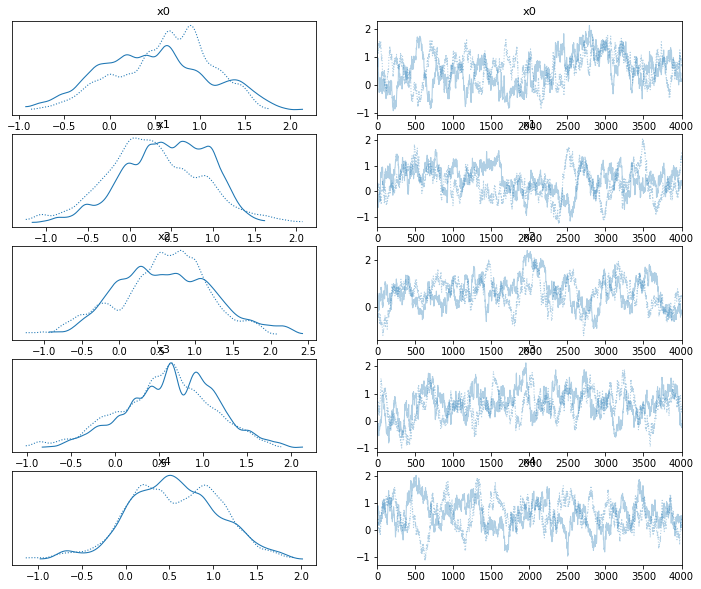

In [ ]:
az.plot_trace(idata)
plt.show()

## Neural Network


In [ ]:
real_x = np.linspace([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 400  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

In [ ]:
A_MF=Model(forward=MF_wrapper, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
y_obs=y_MF(x_MF=real_x).sample()
posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_MF=MH(posterior_MF,x0=x_init)
samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

samplesMH_MF.plot_trace()
samplesMH_MF.mean()
samplesMH_MF.compute_ess()
samplesMH_MF.plot_autocorrelation()

### Low fidelity

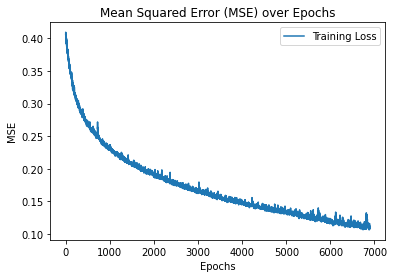

Test MSE: 0.045842277770442044
R^2: 0.6275795035753469


In [ ]:

name="LF"
K.clear_session()
best_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
modelLF=Neural_network(name,params=best_params,data_train=reaction_LF,output_train=U_train_LF,N=Nepo[0],n=batch_size[0],train=True,do_HPO=False,verbose=False)


ULF = modelLF.prediction(reaction_LF_test_original)
(test_mse_LF,r2_LF) = modelLF.performance(reaction_LF_test_original,U_LF_test_original)



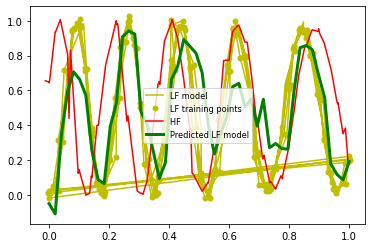

In [ ]:
plt.figure()
plt.plot(
reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
)
plt.plot(
reaction_LF[:, 0],
U_train_LF,
"yo",
markersize=5,
label="LF training points",
)
order=np.argsort(reaction_HF[:,0])
plt.plot(
reaction_HF[order, 0],
U_HF[order],
"r-",
markersize=5,
label="HF ",
)
plt.plot(
reaction_LF_test_original[:, 0],
ULF,
"g-",
linewidth=3,
label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

### High Fidelity

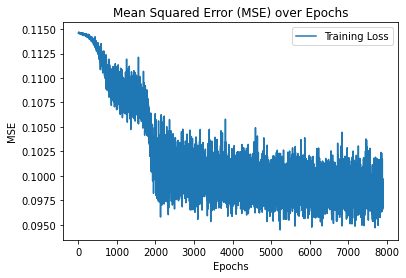

Test MSE: 0.09966862095636868
R^2: 0.11952571575955284


In [ ]:

name="HF"
K.clear_session()
best_params ={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

modelHF=Neural_network(name,params=best_params,data_train=reaction_HF,output_train=U_HF,N=Nepo[1],n=batch_size[1],train=True,do_HPO=False,verbose=False)


UHF = modelHF.prediction(reaction_HF_test_original)
(test_mse_HF,r2_HF) = modelHF.performance(reaction_HF_test_original,U_HF_test_original)



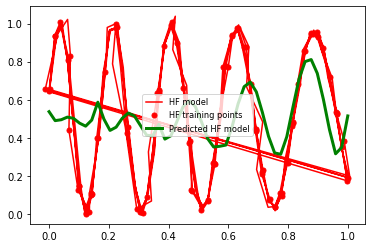

In [ ]:
plt.figure()
plt.plot(
reaction_HF_test[:, 0], U_HF_test, "r-", linewidth=1.5, label="HF model"
)
plt.plot(
reaction_HF[:, 0],
U_HF,
"ro",
markersize=5,
label="HF training points",
)
plt.plot(
reaction_HF_test_original[:, 0],
UHF,
"g-",
linewidth=3,
label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

### Multifidelity

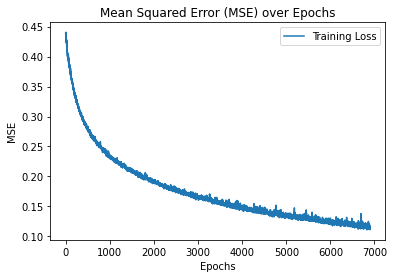

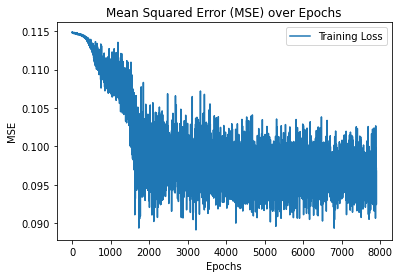

Test MSE: 0.10099531834218708
R^2: 0.1078056486012694


In [ ]:
##########################       FIRST NN: NN_LF     ##########################
K.clear_session()
names=["LF","2step"]

bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
}  # obtained
bestHF_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params=[bestLF_params, bestHF_params]


final_model= MultiFidelity(names,params=params,data_train_LF=reaction_LF,output_train_LF=U_train_LF,data_train_HF=reaction_HF, output_train_HF=U_HF,N=Nepo,n=batch_size,verbose=False)




input_HF = np.concatenate(
    (reaction_HF_test_original,  final_model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
)  # <- TRAINING INPUT for the second NN: NN_HF

input_HF_train = np.concatenate(
    (reaction_HF,  final_model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
) 

(test_mse_HF,r2_HF) = final_model.model_list[1].performance(input_HF,U_HF_test_original)



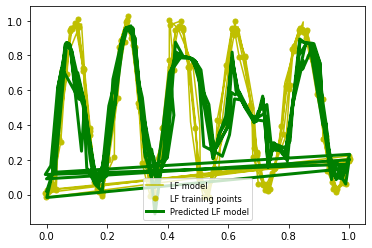

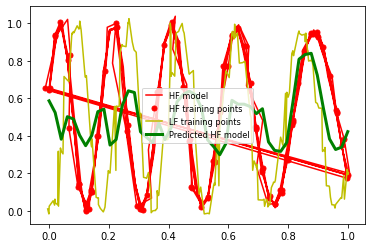

In [ ]:


                
plt.figure()
plt.plot(
reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
)
plt.plot(
reaction_LF[:, 0],
U_train_LF,
"yo",
markersize=5,
label="LF training points",
)
plt.plot(
reaction_LF_test[:, 0],
final_model.model_list[0].prediction(reaction_LF_test),
"g-",
linewidth=3,
label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

plt.figure()
plt.plot(
reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model"
)
plt.plot(
input_HF_train[:, 0],
U_HF,
"ro",
markersize=5,
label="HF training points",
)


order=np.argsort(reaction_LF[:,0])

plt.plot(
reaction_LF[order,0],
U_train_LF[order],
"y-",
markersize=5,
label="LF training points",
)
plt.plot(
input_HF[:, 0],
final_model.model_list[1].prediction(input_HF),
"g-",
linewidth=3,
label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

## MCMC

In [ ]:
real_x=reaction_HF_test
observed_output=U_HF_test

# Set parameters for the MCMC
n_samples = 400  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

In [ ]:
# ATTENZIONE!  in caso LF non si dovrebbe mettere comunque forward=modelHF?


A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_LF=Gaussian(mean=A_LF(x_LF),cov=proposal_sd)
y_obs=y_LF(x_LF=real_x).sample()
posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_LF=MH(posterior_LF,x0=x_init)
samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,n_samples)    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two

samplesMH_LF.plot_trace()
print("mean value")
print(samplesMH_LF.mean())
print("ESS")
print(samplesMH_LF.compute_ess())
samplesMH_LF.plot_autocorrelation()

ValueError: operands could not be broadcast together with shapes (250,1) (5,1) 

In [ ]:
A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
y_obs=y_HF(x_HF=real_x).sample()
posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_HF=MH(posterior_HF,x0=x_init)
samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

samplesMH_HF.plot_trace()
print(samplesMH_HF.mean())
print(samplesMH_HF.compute_ess())
samplesMH_HF.plot_autocorrelation()

In [ ]:
A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
y_obs=y_MF(x_MF=real_x).sample()
posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_MF=MH(posterior_MF,x0=x_init)
samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

samplesMH_MF.plot_trace()
samplesMH_MF.mean()
samplesMH_MF.compute_ess()
samplesMH_MF.plot_autocorrelation()